<a href="https://colab.research.google.com/github/20266588-sudo/20260917ML/blob/main/ML_%EC%88%98%EC%97%85_%EC%8B%A4%EC%8A%B5_260917_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HELLO 🚗

변수와 변수형

In [5]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [6]:
import os
import pandas as pd

# List the contents of the directory
print(os.listdir(path))

['hashes.txt', 'Reviews.csv', 'database.sqlite']


It looks like there's a `Reviews.csv` file. Let's load it into a pandas DataFrame and display the first few rows.

In [7]:
df = pd.read_csv(os.path.join(path, 'Reviews.csv'))
display(df.head())

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re

# Download necessary NLTK data (run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab') # Add download for punkt_tab
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
    tokens = word_tokenize(text) # Tokenize
    filtered_tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    return " ".join(filtered_tokens)

# Apply preprocessing to the 'Text' column
df['CleanedText'] = df['Text'].apply(preprocess_text)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for now

# Fit and transform the 'CleanedText' data
X = tfidf_vectorizer.fit_transform(df['CleanedText'])
y = df['Score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Text preprocessing and TF-IDF vectorization complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Text preprocessing and TF-IDF vectorization complete.
Shape of X_train: (454763, 5000)
Shape of X_test: (113691, 5000)


### 2.1. 모델 훈련 (로지스틱 회귀)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train a Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model training complete.")

Logistic Regression model training complete.


### 2.2. 모델 평가

In [19]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)


Accuracy: 0.7369
Classification Report:
              precision    recall  f1-score   support

           1       0.65      0.67      0.66     10326
           2       0.46      0.22      0.30      5855
           3       0.45      0.29      0.35      8485
           4       0.50      0.24      0.33     16123
           5       0.80      0.95      0.87     72902

    accuracy                           0.74    113691
   macro avg       0.57      0.47      0.50    113691
weighted avg       0.70      0.74      0.70    113691



### 2.3. 혼동 행렬 시각화

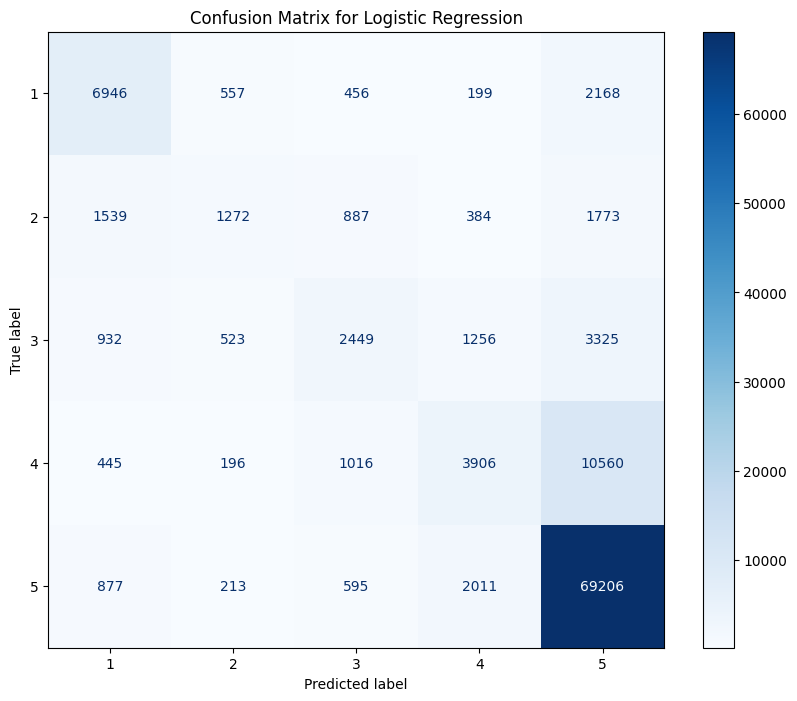

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(log_reg_model, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Logistic Regression')
plt.show()

## 3. BERT 모델을 이용한 Score 예측 (어텐션 기반)

### 3.1. 라이브러리 설치 및 임포트

In [24]:
!pip install transformers datasets accelerate -qq

In [2]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from torch.optim import AdamW # Corrected import for AdamW
from transformers.optimization import get_linear_schedule_with_warmup # get_linear_schedule_with_warmup remains here
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

### 3.2. BERT 토크나이징 및 데이터 준비

In [8]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Encode the training and test data
# We'll use the original 'Text' column for BERT, as it handles its own preprocessing
encoded_data_train = tokenizer(
    df['Text'].loc[y_train.index].tolist(), # Get original text for training set using y_train.index
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    max_length=256,
    truncation=True, # Add truncation for texts longer than max_length
    return_tensors='pt'
)

encoded_data_val = tokenizer(
    df['Text'].loc[y_test.index].tolist(), # Get original text for validation set using y_test.index
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    max_length=256,
    truncation=True, # Add truncation for texts longer than max_length
    return_tensors='pt'
)

input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
# BERT expects labels to be 0-indexed, so we subtract 1 from the original scores (1-5 -> 0-4)
labels_train = torch.tensor(y_train.values - 1)

input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
labels_val = torch.tensor(y_test.values - 1)

# Create TensorDatasets
dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

# Define batch size
batch_size = 32

# Create DataLoaders
dataloader_train = DataLoader(
    dataset_train,
    sampler=RandomSampler(dataset_train),
    batch_size=batch_size
)

dataloader_validation = DataLoader(
    dataset_val,
    sampler=SequentialSampler(dataset_val),
    batch_size=batch_size
)

print("BERT Tokenization and DataLoader creation complete.")

NameError: name 'y_train' is not defined